In [1]:
# ==============================
# DEVELOPED INTRUSION DETECTION SYSTEM
# For Network Malicious Detection (IDS/IPS)
# With Comprehensive Validation & Analysis
# MODIFIED: Removed validation set, using only train/test split (70/30) + CV
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, f1_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             roc_auc_score, classification_report, matthews_corrcoef,
                             balanced_accuracy_score, cohen_kappa_score)
from sklearn.utils import shuffle, resample
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
import time
import shap
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")

C:\Users\Nooruddine\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INTRUSION DETECTION SYSTEM
Network Malicious Detection (Benign vs Malicious)
All IDSAI Dataset shape: (1000000, 26)
Dataset after drop duplicates: (693116, 26)
Label (Benign and Malicious) counts:
label
1    471256
0    221860
Name: count, dtype: int64

Features after cleaning: 21

Data split: Train=485181 (70%), Test=207935 (30%)

Training model...
Training time: 132.98 seconds

Cross-Validation (on training set)...
10-Fold CV Accuracy on Train: 0.9994 ± 0.0001

PERFORMANCE SUMMARY
Accuracy        | Train: 99.95% | Test: 99.95%
Balanced Acc    | Train: 99.94% | Test: 99.94%
Precision       | Train: 99.95% | Test: 99.95%
Recall          | Train: 99.95% | Test: 99.95%
F1              | Train: 99.95% | Test: 99.95%
MCC             | Train: 99.88% | Test: 99.89%
Kappa           | Train: 99.88% | Test: 99.89%
Specificity     | Train: 99.90% | Test: 99.92%
Sensitivity     | Train: 99.97% | Test: 99.97%
AUC             | Train: 0.00% | Test: 100.00%


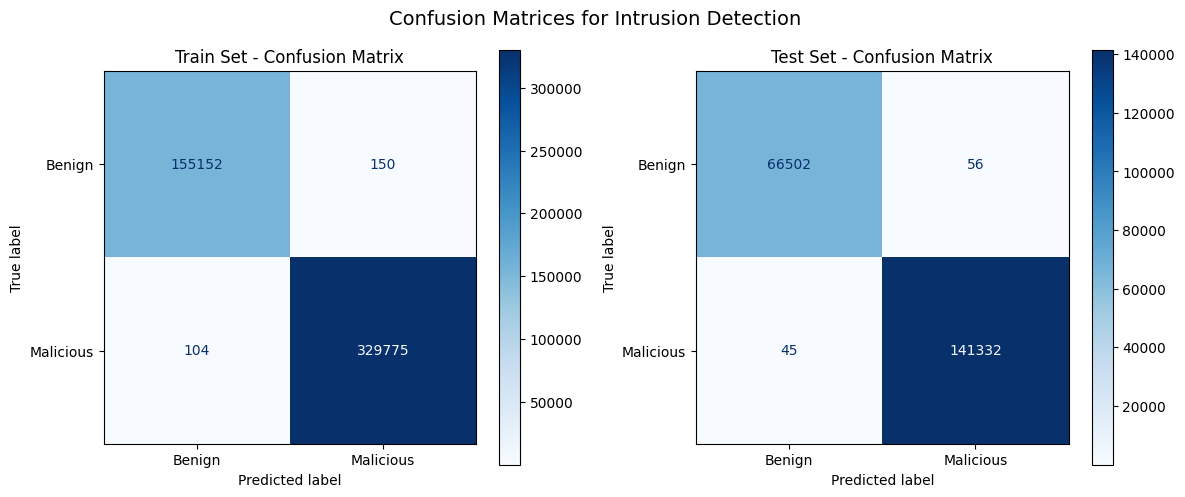

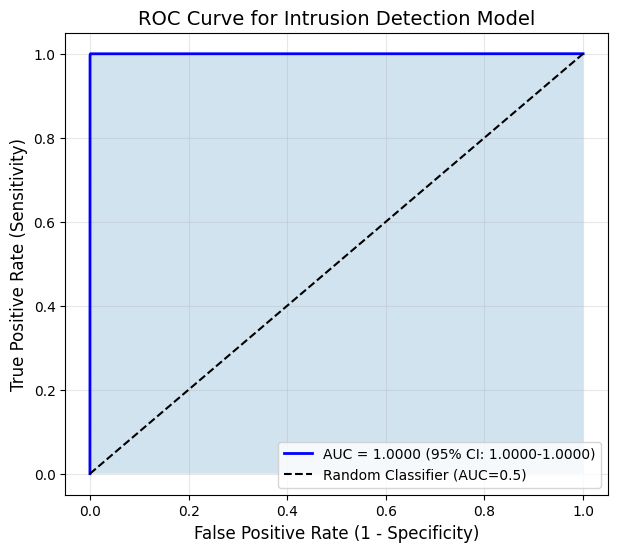

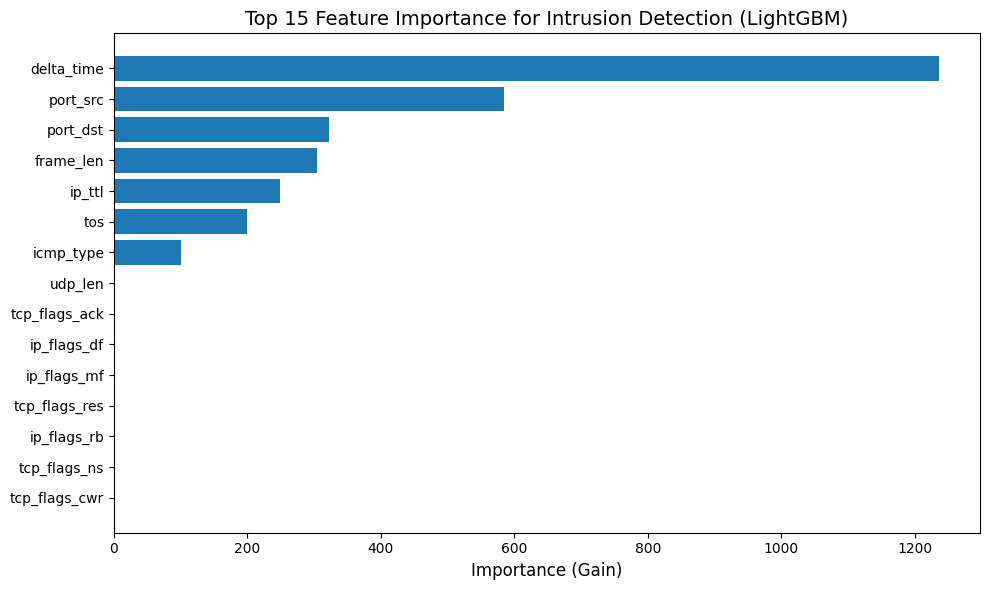


Top 10 features:
           Feature  Importance
0      delta_time        1236
1        port_src         585
2        port_dst         322
3       frame_len         304
5          ip_ttl         249
7             tos         200
6       icmp_type         100
4         udp_len           2
16  tcp_flags_ack           2
9     ip_flags_df           0

SHAP analysis (sampling 100 test samples)...

FEATURE IMPORTANCE BASED ON SHAP

Feature                        Strength     Impact %  
------------------------------------------------------------
frame_len                      3.2581       47.41     
port_dst                       1.3421       19.53     
tos                            0.9327       13.57     
port_src                       0.7628       11.10     
ip_ttl                         0.3880       5.65      
icmp_type                      0.1389       2.02      
delta_time                     0.0479       0.70      
tcp_flags_ack                  0.0019       0.03      
udp_len       

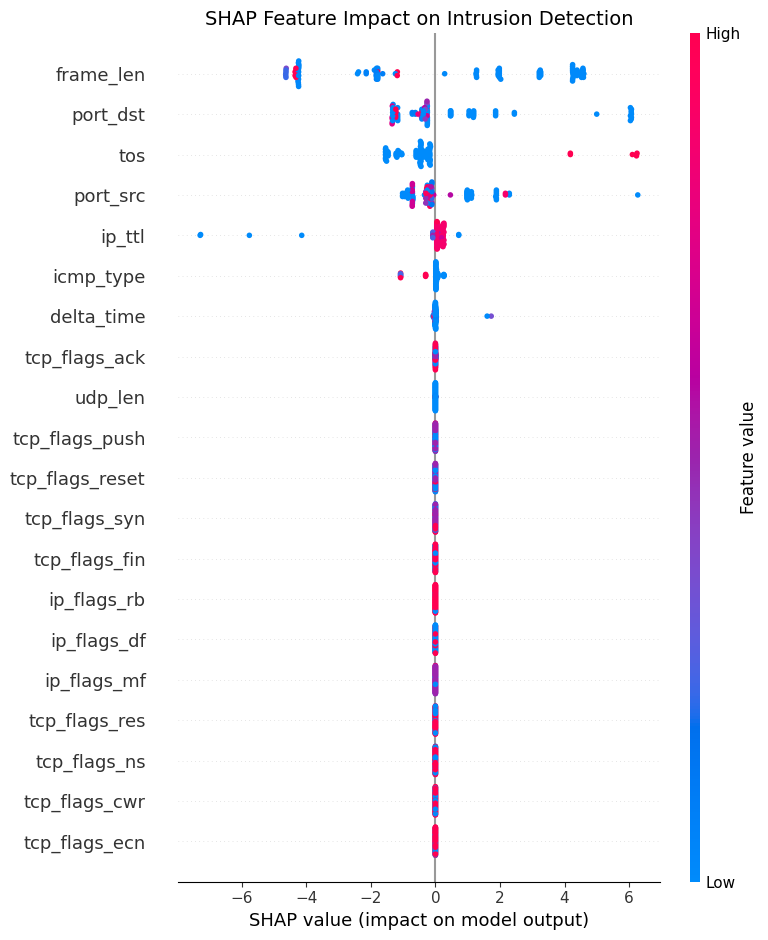

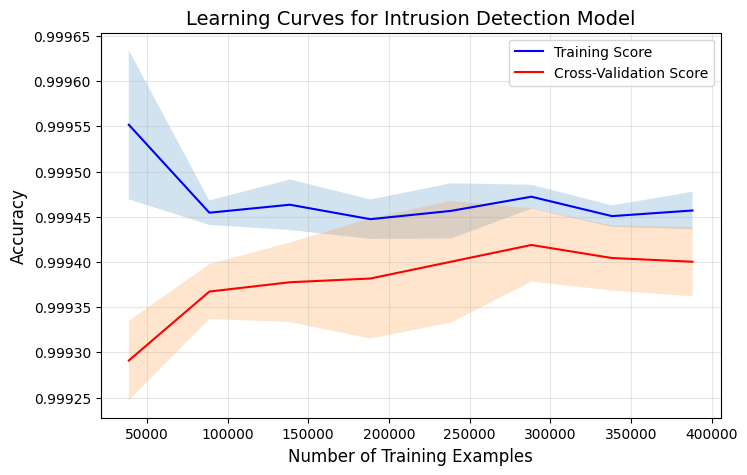


Comparing with individual models on test set...
          Accuracy  Balanced Acc  Precision  Recall      F1     MCC   Kappa  \
xgb         0.9995        0.9994     0.9995  0.9995  0.9995  0.9989  0.9989   
Ensemble    0.9995        0.9994     0.9995  0.9995  0.9995  0.9989  0.9989   
lgb         0.9995        0.9994     0.9995  0.9995  0.9995  0.9988  0.9988   

          Specificity  Sensitivity  AUC  
xgb            0.9991       0.9997  1.0  
Ensemble       0.9992       0.9997  1.0  
lgb            0.9993       0.9996  1.0  


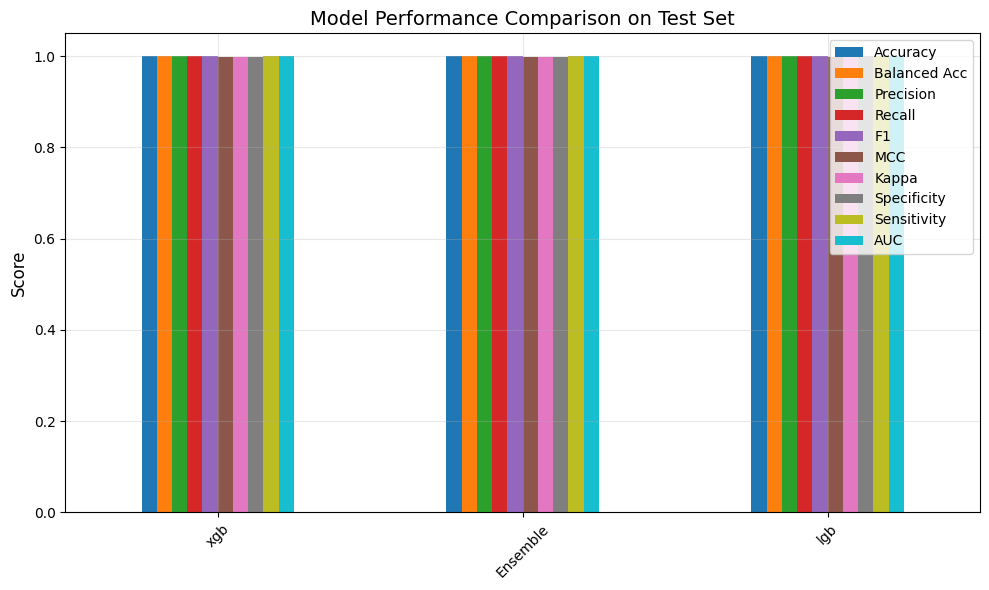


McNemar's test (Ensemble vs Logistic Regression): p-value = 0.000000
Result: Statistically significant difference (p < 0.05)

Model saved to fast_ids_model.pkl

FINAL CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     66558
   Malicious       1.00      1.00      1.00    141377

    accuracy                           1.00    207935
   macro avg       1.00      1.00      1.00    207935
weighted avg       1.00      1.00      1.00    207935


INTRUSION DETECTION SYSTEM - COMPLETED SUCCESSFULLY
Results saved in: ids_results/

Sample predictions on test instances:
  Correct | True: Benign    | Predicted: Benign   
  Correct | True: Malicious | Predicted: Malicious
  Correct | True: Malicious | Predicted: Malicious
  Correct | True: Benign    | Predicted: Benign   
  Correct | True: Benign    | Predicted: Benign   

Total execution time: 14.17 minutes


In [2]:

start_time = time.time()

# ==============================
# 1. CONFIGURATION
# ==============================
class Config:
    RANDOM_STATE = 42
    TEST_SIZE = 0.3
    N_FOLDS = 10
    N_JOBS = -1
    MODEL_SAVE_PATH = "fast_ids_model.pkl"
    RESULTS_PATH = "ids_results/"

    LGB_PARAMS = {
        'n_estimators': 100,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'random_state': RANDOM_STATE,
        'n_jobs': N_JOBS,
        'class_weight': 'balanced',
        'verbose': -1
    }

    XGB_PARAMS = {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'max_depth': 6,
        'random_state': RANDOM_STATE,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'n_jobs': N_JOBS
    }

config = Config()
import os
os.makedirs(config.RESULTS_PATH, exist_ok=True)

# ==============================
# 2. DATA LOADING & BALANCING
# ==============================
print("="*60)
print("INTRUSION DETECTION SYSTEM")
print("Network Malicious Detection (Benign vs Malicious)")
print("="*60)

df = pd.read_csv('IDSAI.csv')
print(f"All IDSAI Dataset shape: {df.shape}")

df.drop_duplicates(inplace=True)
print(f"Dataset after drop duplicates: {df.shape}")

print("="*60)
print(f"Label (Benign and Malicious) counts:\n{df['label'].value_counts()}")


# ==============================
# 3. FEATURE SELECTION (Drop irrelevant columns)
# ==============================
X = df.drop(['label', 'tipo_ataque', 'ip_src', 'ip_dst', 'protocols'], axis=1)
y = df['label']
print(f"\nFeatures after cleaning: {X.shape[1]}")

# ==============================
# 4. SINGLE TRAIN/TEST SPLIT (70/30)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
)


print(f"\nData split: Train={len(X_train)} ({100*(1-config.TEST_SIZE):.0f}%), Test={len(X_test)} ({100*config.TEST_SIZE:.0f}%)")

# ==============================
# 5. DEFINE MODELS AND ENSEMBLE
# ==============================
models = {
    'xgb': XGBClassifier(**config.XGB_PARAMS),
    'lgb': lgb.LGBMClassifier(**config.LGB_PARAMS),
}

voted_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft',
    weights=[2, 2]
)

# ==============================
# 6. BUILD PIPELINE (Only scaling)
# ==============================
full_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('ensemble', voted_clf)
])

# ==============================
# 7. TRAINING
# ==============================
print("\nTraining model...")
train_start = time.time()
full_pipeline.fit(X_train, y_train)
train_time = time.time() - train_start
print(f"Training time: {train_time:.2f} seconds")

# ==============================
# 8. CROSS-VALIDATION (ON TRAINING SET ONLY)
# ==============================
print("\nCross-Validation (on training set)...")
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=config.N_JOBS)
print(f"{config.N_FOLDS}-Fold CV Accuracy on Train: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ==============================
# 9. EVALUATION FUNCTION (only on train and test)
# ==============================
def evaluate(model, X_train, X_test, y_train, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    def metrics(y_true, y_pred, y_proba=None):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted'),
            'Recall': recall_score(y_true, y_pred, average='weighted'),
            'F1': f1_score(y_true, y_pred, average='weighted'),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'Kappa': cohen_kappa_score(y_true, y_pred),
            'Specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
            'Sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
            'AUC': roc_auc_score(y_true, y_proba) if y_proba is not None else 0
        }

    train_metrics = metrics(y_train, train_pred)
    test_metrics = metrics(y_test, test_pred, test_proba)
    return train_metrics, test_metrics, test_pred, test_proba

train_m, test_m, test_pred, test_proba = evaluate(full_pipeline, X_train, X_test, y_train, y_test)

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
for metric in test_m:
    print(f"{metric:15} | Train: {train_m[metric]*100:.2f}% | Test: {test_m[metric]*100:.2f}%")

# ==============================
# 10. CONFUSION MATRICES (Train and Test)
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, name, y_d, preds in zip(axes, ['Train','Test'], [y_train, y_test],
                                 [full_pipeline.predict(X_train), test_pred]):
    cm = confusion_matrix(y_d, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malicious'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{name} Set - Confusion Matrix')
plt.suptitle('Confusion Matrices for Intrusion Detection', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}confusion_matrices.png', dpi=150)
plt.show()

# ==============================
# 11. ROC CURVE WITH CONFIDENCE INTERVAL (on Test set)
# ==============================
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_val = test_m['AUC']

# Bootstrap CI
aucs_boot = []
rng = np.random.RandomState(config.RANDOM_STATE)
for _ in range(500):
    idx = rng.choice(len(y_test), len(y_test), replace=True)
    if len(np.unique(y_test.iloc[idx])) < 2:
        continue
    aucs_boot.append(roc_auc_score(y_test.iloc[idx], test_proba[idx]))
ci_low, ci_high = np.percentile(aucs_boot, [2.5, 97.5])

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.4f} (95% CI: {ci_low:.4f}-{ci_high:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve for Intrusion Detection Model', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(f'{config.RESULTS_PATH}roc_curve.png', dpi=150)
plt.show()

# ==============================
# 12. FEATURE IMPORTANCE (LightGBM)
# ==============================
lgb_model = full_pipeline.named_steps['ensemble'].named_estimators_['lgb']
X_train_scaled = full_pipeline.named_steps['scaler'].transform(X_train)
importances = lgb_model.feature_importances_
feature_names = X_train.columns

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(imp_df['Feature'][:15][::-1], imp_df['Importance'][:15][::-1])
plt.xlabel('Importance (Gain)', fontsize=12)
plt.title('Top 15 Feature Importance for Intrusion Detection (LightGBM)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}feature_importance.png', dpi=150)
plt.show()
print("\nTop 10 features:\n", imp_df.head(10))

# ==============================
# 13. SHAP ANALYSIS (on test set sample)
# ==============================
try:
    print("\nSHAP analysis (sampling 100 test samples)...")
    X_test_sampled = X_test[:100]
    X_test_scaled = full_pipeline.named_steps['scaler'].transform(X_test_sampled)
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    importance_percentage = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_results = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Strength': mean_abs_shap, 
        'Impact_%': importance_percentage  
    }).sort_values('SHAP_Strength', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE BASED ON SHAP")
    print("="*60)
    print(f"\n{'Feature':<30} {'Strength':<12} {'Impact %':<10}")
    print("-"*60)
    
    for i, row in shap_results.head(15).iterrows():
        print(f"{row['Feature']:<30} {row['SHAP_Strength']:<12.4f} {row['Impact_%']:<10.2f}")
    
    print("="*60)
    print(f"\nTop feature: {shap_results.iloc[0]['Feature']} (Impact: {shap_results.iloc[0]['Impact_%']:.2f}%)")
    print(f"Second feature: {shap_results.iloc[1]['Feature']} (Impact: {shap_results.iloc[1]['Impact_%']:.2f}%)")
    print(f"Third feature: {shap_results.iloc[2]['Feature']} (Impact: {shap_results.iloc[2]['Impact_%']:.2f}%)")
    
    shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Impact on Intrusion Detection', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}shap_summary.png', dpi=150)
    plt.show()
    
except Exception as e:
    print(f"SHAP skipped: {e}")

# ==============================
# 14. LEARNING CURVES (using train/test split, not validation)
# ==============================
train_sizes, train_scores, val_scores = learning_curve(
    full_pipeline, X_train, y_train, cv=5, train_sizes=np.linspace(0.1,1,8),
    scoring='accuracy', n_jobs=config.N_JOBS)
train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
val_mean, val_std = np.mean(val_scores, axis=1), np.std(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'b-', label='Training Score')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 'r-', label='Cross-Validation Score')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curves for Intrusion Detection Model', fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.savefig(f'{config.RESULTS_PATH}learning_curves.png', dpi=150)
plt.show()

# ==============================
# 15. COMPARISON WITH INDIVIDUAL MODELS (on test set)
# ==============================
print("\nComparing with individual models on test set...")
comparison = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', RobustScaler()), ('clf', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    comp = {
        'Accuracy': accuracy_score(y_test, pred),
        'Balanced Acc': balanced_accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall': recall_score(y_test, pred, average='weighted'),
        'F1': f1_score(y_test, pred, average='weighted'),
        'MCC': matthews_corrcoef(y_test, pred),
        'Kappa': cohen_kappa_score(y_test, pred),
        'Specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
        'Sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
        'AUC': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    }
    comparison[name] = comp
comparison['Ensemble'] = {
    'Accuracy': test_m['Accuracy'], 
    'Balanced Acc': test_m['Balanced Acc'], 
    'Precision': test_m['Precision'],
    'Accuracy': test_m['Accuracy'], 
    'Recall': test_m['Recall'], 
    'F1': test_m['F1'],
    'MCC': test_m['MCC'], 
    'Kappa': test_m['Kappa'], 
    'Specificity': test_m['Specificity'],
    'Sensitivity': test_m['Sensitivity'],
    'AUC': test_m['AUC']
    }
comp_df = pd.DataFrame(comparison).T.sort_values('Accuracy', ascending=False)
print(comp_df.round(4))

comp_df.plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison on Test Set', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}model_comparison.png', dpi=150)
plt.show()

# ==============================
# 16. MCNEMAR'S TEST (Ensemble vs Logistic Regression)
# ==============================
base_pipe = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
base_pipe.fit(X_train, y_train)
base_pred = base_pipe.predict(X_test)
contingency = pd.crosstab(test_pred, base_pred)
mcnemar_res = mcnemar(contingency, exact=True)
print(f"\nMcNemar's test (Ensemble vs Logistic Regression): p-value = {mcnemar_res.pvalue:.6f}")
if mcnemar_res.pvalue < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

# ==============================
# 17. SAVE MODEL AND RESULTS
# ==============================
joblib.dump(full_pipeline, config.MODEL_SAVE_PATH)
print(f"\nModel saved to {config.MODEL_SAVE_PATH}")

summary = pd.DataFrame([{
    'Train_Time_sec': train_time,
    'CV_Mean_Accuracy': cv_scores.mean(),
    'CV_Std': cv_scores.std(),
    'Test_Accuracy': test_m['Accuracy'],
    'Test_F1': test_m['F1'],
    'Test_AUC': test_m['AUC'],
    'Test_MCC': test_m['MCC'],
    'Test_Sensitivity': test_m['Sensitivity'],
    'Test_Specificity': test_m['Specificity']
}])
summary.to_csv(f'{config.RESULTS_PATH}summary.csv', index=False)

# ==============================
# 18. FINAL CLASSIFICATION REPORT
# ==============================
print("\n" + "="*60)
print("FINAL CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, test_pred, target_names=['Benign', 'Malicious']))

print("\n" + "="*60)
print("INTRUSION DETECTION SYSTEM - COMPLETED SUCCESSFULLY")
print(f"Results saved in: {config.RESULTS_PATH}")
print("="*60)

# ==============================
# 19. SAMPLE PREDICTIONS
# ==============================
sample_idx = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)
print("\nSample predictions on test instances:")
for idx in sample_idx:
    true_label = "Malicious" if y_test.iloc[idx] == 1 else "Benign"
    pred_label = "Malicious" if full_pipeline.predict(X_test.iloc[[idx]])[0] == 1 else "Benign"
    status = "Correct" if y_test.iloc[idx] == full_pipeline.predict(X_test.iloc[[idx]])[0] else "Wrong"
    print(f"  {status:7} | True: {true_label:9} | Predicted: {pred_label:9}")

total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time/60:.2f} minutes")
print("="*60)


SHAP analysis (sampling 500 test samples)...

FEATURE IMPORTANCE BASED ON SHAP

Feature                        Strength     Impact %  
------------------------------------------------------------
frame_len                      3.2889       48.39     
port_dst                       1.1705       17.22     
tos                            0.9875       14.53     
port_src                       0.9077       13.35     
ip_ttl                         0.2645       3.89      
icmp_type                      0.1443       2.12      
delta_time                     0.0315       0.46      
tcp_flags_ack                  0.0019       0.03      
udp_len                        0.0000       0.00      
ip_flags_df                    0.0000       0.00      
ip_flags_mf                    0.0000       0.00      
tcp_flags_res                  0.0000       0.00      
ip_flags_rb                    0.0000       0.00      
tcp_flags_ns                   0.0000       0.00      
tcp_flags_cwr                  0.

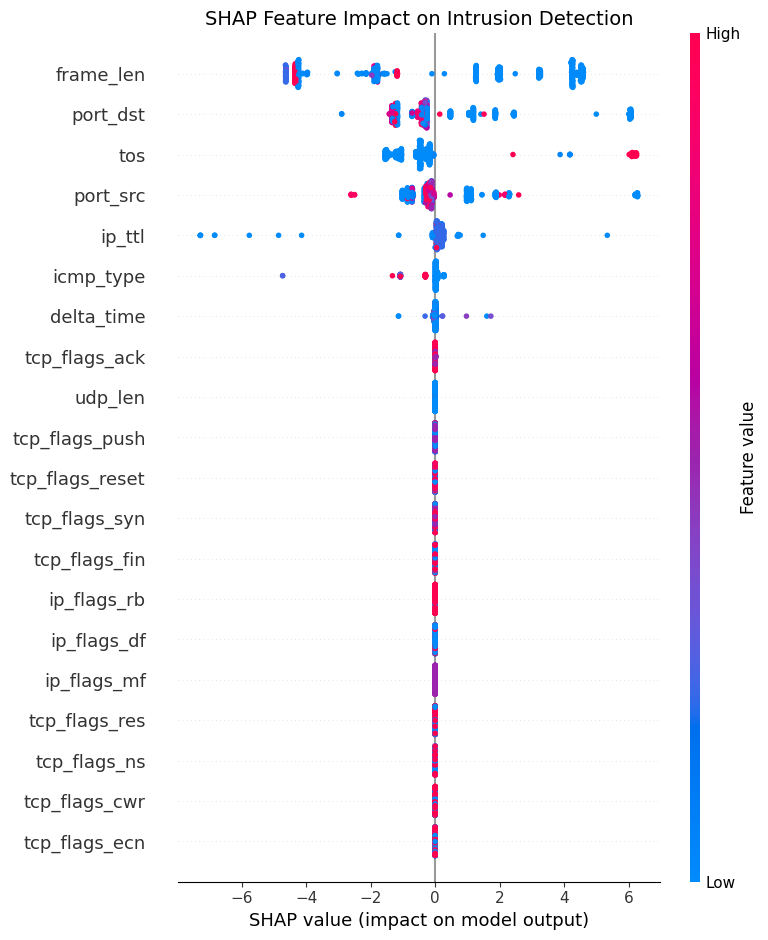

In [ ]:
# ==============================
# 13. SHAP ANALYSIS (on test set sample)
# ==============================
try:
    print("\nSHAP analysis (sampling 500 test samples)...")
    X_test_sampled = X_test[:500]
    X_test_scaled = full_pipeline.named_steps['scaler'].transform(X_test_sampled)
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    importance_percentage = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_results = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Strength': mean_abs_shap,  
        'Impact_%': importance_percentage  
    }).sort_values('SHAP_Strength', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE BASED ON SHAP")
    print("="*60)
    print(f"\n{'Feature':<30} {'Strength':<12} {'Impact %':<10}")
    print("-"*60)
    
    for i, row in shap_results.head(15).iterrows():
        print(f"{row['Feature']:<30} {row['SHAP_Strength']:<12.4f} {row['Impact_%']:<10.2f}")
    
    print("="*60)
    print(f"\nTop feature: {shap_results.iloc[0]['Feature']} (Impact: {shap_results.iloc[0]['Impact_%']:.2f}%)")
    print(f"Second feature: {shap_results.iloc[1]['Feature']} (Impact: {shap_results.iloc[1]['Impact_%']:.2f}%)")
    print(f"Third feature: {shap_results.iloc[2]['Feature']} (Impact: {shap_results.iloc[2]['Impact_%']:.2f}%)")
    
    shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Impact on Intrusion Detection', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}shap_summary.png', dpi=150)
    plt.show()
    
except Exception as e:
    print(f"SHAP skipped: {e}")


SHAP analysis (sampling 1000 test samples)...

FEATURE IMPORTANCE BASED ON SHAP

Feature                        Strength     Impact %  
------------------------------------------------------------
frame_len                      3.2549       47.74     
port_dst                       1.1539       16.92     
tos                            1.0165       14.91     
port_src                       0.9295       13.63     
ip_ttl                         0.2849       4.18      
icmp_type                      0.1460       2.14      
delta_time                     0.0297       0.44      
tcp_flags_ack                  0.0020       0.03      
udp_len                        0.0001       0.00      
ip_flags_df                    0.0000       0.00      
ip_flags_mf                    0.0000       0.00      
tcp_flags_res                  0.0000       0.00      
ip_flags_rb                    0.0000       0.00      
tcp_flags_ns                   0.0000       0.00      
tcp_flags_cwr                  0

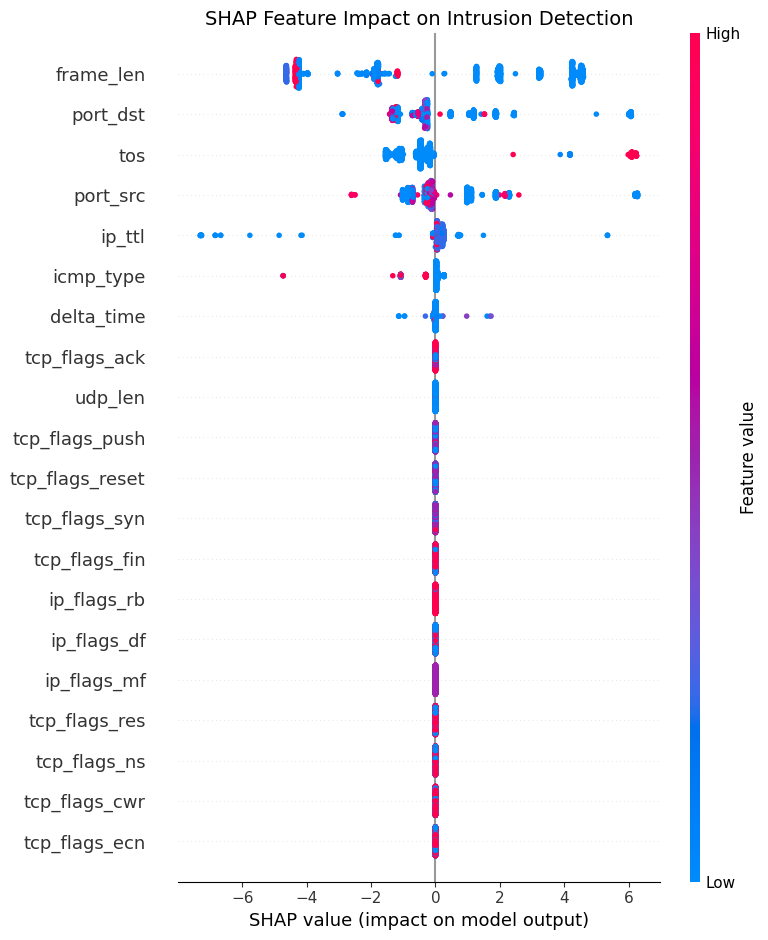

In [4]:
# ==============================
# 13. SHAP ANALYSIS (on test set sample)
# ==============================
try:
    print("\nSHAP analysis (sampling 1000 test samples)...")
    X_test_sampled = X_test[:1000]
    X_test_scaled = full_pipeline.named_steps['scaler'].transform(X_test_sampled)
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    importance_percentage = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_results = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Strength': mean_abs_shap, 
        'Impact_%': importance_percentage  
    }).sort_values('SHAP_Strength', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE BASED ON SHAP")
    print("="*60)
    print(f"\n{'Feature':<30} {'Strength':<12} {'Impact %':<10}")
    print("-"*60)
    
    for i, row in shap_results.head(15).iterrows():
        print(f"{row['Feature']:<30} {row['SHAP_Strength']:<12.4f} {row['Impact_%']:<10.2f}")
    
    print("="*60)
    print(f"\nTop feature: {shap_results.iloc[0]['Feature']} (Impact: {shap_results.iloc[0]['Impact_%']:.2f}%)")
    print(f"Second feature: {shap_results.iloc[1]['Feature']} (Impact: {shap_results.iloc[1]['Impact_%']:.2f}%)")
    print(f"Third feature: {shap_results.iloc[2]['Feature']} (Impact: {shap_results.iloc[2]['Impact_%']:.2f}%)")
    
    shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Impact on Intrusion Detection', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}shap_summary.png', dpi=150)
    plt.show()
    
except Exception as e:
    print(f"SHAP skipped: {e}")